In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sales = pd.read_csv("/content/sales_integrated.csv")
products = pd.read_csv("/content/products_clean.csv")

print("Sales shape:", sales.shape)
print("Products shape:", products.shape)


Sales shape: (130402, 55)
Products shape: (30, 23)


In [3]:
# Inspect Columns
print("Sales columns:")
print(sales.columns.tolist())

print("\nProduct columns:")
print(products.columns.tolist())

Sales columns:
['so_id', 'line_number', 'product_id', 'quantity', 'unit_price', 'gst_rate', 'line_total', 'gst_amount', 'line_grand_total', 'customer_id', 'branch_id', 'order_date', 'delivery_date', 'order_status', 'payment_terms', 'total_order_value', 'total_gst_amount', 'grand_total', 'sales_channel', 'product_name', 'category', 'machine_type', 'brand', 'model_compatibility', 'unit_cost', 'unit_price_product', 'margin_percentage', 'gst_rate_product', 'weight_kg', 'dimensions_cm', 'material_type', 'warranty_months', 'reorder_level', 'safety_stock', 'max_stock_level', 'lead_time_days', 'criticality_level', 'usage_frequency', 'uom', 'last_purchase_price', 'last_purchase_date', 'customer_type', 'industry_segment', 'city', 'state', 'pincode', 'region', 'branch_id_customer', 'credit_limit', 'current_balance', 'payment_terms_customer', 'customer_since', 'last_purchase_date_customer', 'total_purchase_value', 'customer_rating']

Product columns:
['product_id', 'product_name', 'category', 'mac

In [4]:
# Confirm the Product Relationship
print("Sales product IDs:")
print(sales["product_id"].head())

print("\nProduct IDs:")
print(products["product_id"].head())

Sales product IDs:
0    P018
1    P026
2    P026
3    P013
4    P004
Name: product_id, dtype: object

Product IDs:
0    P001
1    P002
2    P003
3    P004
4    P005
Name: product_id, dtype: object


In [5]:
# Check unmatched products
sales_product_ids = set(sales["product_id"].dropna().unique())
product_ids = set(products["product_id"].dropna().unique())

unmatched_products = sales_product_ids - product_ids

print("Number of unmatched product IDs:", len(unmatched_products))

Number of unmatched product IDs: 0


### **Create the product-sales dataset**

In [6]:
# Merge the datasets
product_sales = sales.merge(
    products,
    on="product_id",
    how="left",
    suffixes=("_sales", "_product")
)

print("Integrated dataset shape:", product_sales.shape)
display(product_sales.head())

Integrated dataset shape: (130402, 77)


,so_id,line_number,product_id,quantity,unit_price_sales,gst_rate_sales,line_total,gst_amount,line_grand_total,customer_id,...,warranty_months_product,reorder_level_product,safety_stock_product,max_stock_level_product,lead_time_days_product,criticality_level_product,usage_frequency_product,uom_product,last_purchase_price_product,last_purchase_date_product
0,SO-990591,1,P018,19,11300,28,214700,60116.0,274816.0,C0070,...,12,12,6,30,20,High,Medium,piece,8000,2024-02-20
1,SO-990591,2,P026,2,310,18,620,111.6,731.6,C0070,...,3,200,100,500,4,Low,High,cartridge,170,2020-04-02
2,SO-990591,3,P026,3,310,18,930,167.4,1097.4,C0070,...,3,200,100,500,4,Low,High,cartridge,170,2020-04-02
3,SO-990591,4,P013,9,1450,18,13050,2349.0,15399.0,C0070,...,6,80,40,200,9,Medium,High,set,920,2022-12-19
4,SO-990591,5,P004,3,39800,28,119400,33432.0,152832.0,C0070,...,18,8,4,20,30,High,Low,set,32000,2020-06-18


In [7]:
# Check the merged datasets
print("Missing values after merge:")

missing = (
    product_sales.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing[missing > 0])

Missing values after merge:


,0


### Identify sales columns

In [8]:
# Before calculating performance, inspect numeric columns:
print(product_sales.select_dtypes(include=np.number).columns.tolist())

['line_number', 'quantity', 'unit_price_sales', 'gst_rate_sales', 'line_total', 'gst_amount', 'line_grand_total', 'total_order_value', 'total_gst_amount', 'grand_total', 'unit_cost_sales', 'unit_price_product', 'margin_percentage_sales', 'gst_rate_product', 'weight_kg_sales', 'warranty_months_sales', 'reorder_level_sales', 'safety_stock_sales', 'max_stock_level_sales', 'lead_time_days_sales', 'last_purchase_price_sales', 'pincode', 'credit_limit', 'current_balance', 'total_purchase_value', 'customer_rating', 'unit_cost_product', 'unit_price_product', 'margin_percentage_product', 'gst_rate_product', 'weight_kg_product', 'warranty_months_product', 'reorder_level_product', 'safety_stock_product', 'max_stock_level_product', 'lead_time_days_product', 'last_purchase_price_product']


In [13]:
# Required columns for Week 4 product performance analysis

required_columns = [
    "quantity",
    "unit_price_sales",
    "line_total",
    "line_grand_total",
    "unit_cost_sales",
    "margin_percentage_sales"
]

missing_columns = [
    col for col in required_columns
    if col not in product_sales.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required sales columns are available.")

All required sales columns are available.


In [12]:
product_sales[required_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130402 entries, 0 to 130401
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   quantity                 130402 non-null  int64  
 1   unit_price_sales         130402 non-null  int64  
 2   line_total               130402 non-null  int64  
 3   line_grand_total         130402 non-null  float64
 4   unit_cost_sales          130402 non-null  int64  
 5   margin_percentage_sales  130402 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 6.0 MB


### **Calculate Sales Value**

In [16]:
product_sales["sales_value"] = product_sales["line_total"]
print("Total Sales Value: £{:,.2f}".format(
    product_sales["sales_value"].sum()
))

Total Sales Value: £25,447,392,560.00


### **Calculate sales value independently**

In [17]:
product_sales["calculated_sales_value"] = (
    product_sales["quantity"]
    * product_sales["unit_price_sales"]
)

product_sales["sales_value_difference"] = (
    product_sales["line_total"]
    - product_sales["calculated_sales_value"]
)

display(
    product_sales[
        [
            "quantity",
            "unit_price_sales",
            "line_total",
            "calculated_sales_value",
            "sales_value_difference"
        ]
    ].head(10)
)

,quantity,unit_price_sales,line_total,calculated_sales_value,sales_value_difference
0,19,11300,214700,214700,0
1,2,310,620,620,0
2,3,310,930,930,0
3,9,1450,13050,13050,0
4,3,39800,119400,119400,0
5,9,24500,220500,220500,0
6,3,46200,138600,138600,0
7,11,34900,383900,383900,0
8,10,24500,245000,245000,0
9,16,310,4960,4960,0


### **Check whether the difference is significant**

In [18]:
max_difference = (
    product_sales["sales_value_difference"]
    .abs()
    .max()
)

print(
    "Maximum difference between recorded and calculated sales value:",
    round(max_difference, 2)
)

Maximum difference between recorded and calculated sales value: 0


### **Calculate gross cost**

In [19]:
product_sales["total_cost"] = (
    product_sales["quantity"]
    * product_sales["unit_cost_sales"]
)

### **Calculate gross profit**

In [20]:
product_sales["gross_profit"] = (
    product_sales["sales_value"]
    - product_sales["total_cost"]
)

In [21]:
display(
    product_sales[
        [
            "quantity",
            "sales_value",
            "total_cost",
            "gross_profit"
        ]
    ].head(10)
)

,quantity,sales_value,total_cost,gross_profit
0,19,214700,155800,58900
1,2,620,360,260
2,3,930,540,390
3,9,13050,8550,4500
4,3,119400,97500,21900
5,9,220500,170550,49950
6,3,138600,106800,31800
7,11,383900,317900,66000
8,10,245000,189500,55500
9,16,4960,2880,2080


### **Calculate profit margin independently**

In [22]:
product_sales["calculated_margin_percentage"] = np.where(
    product_sales["sales_value"] != 0,
    (
        product_sales["gross_profit"]
        / product_sales["sales_value"]
    ) * 100,
    0
)

# Compare it with the existing margin field:
display(
    product_sales[
        [
            "margin_percentage_sales",
            "calculated_margin_percentage"
        ]
    ].head(10)
)

,margin_percentage_sales,calculated_margin_percentage
0,37.8,27.433628
1,72.2,41.935484
2,72.2,41.935484
3,52.6,34.482759
4,22.5,18.341709
5,29.2,22.653061
6,29.8,22.943723
7,20.8,17.191977
8,29.2,22.653061
9,72.2,41.935484


### **Calculate average selling price**

In [23]:
product_sales["average_unit_price"] = (
    product_sales["sales_value"]
    / product_sales["quantity"].replace(0, np.nan)
)

display(
    product_sales[
        [
            "quantity",
            "sales_value",
            "average_unit_price"
        ]
    ].head(10)
)

,quantity,sales_value,average_unit_price
0,19,214700,11300.0
1,2,620,310.0
2,3,930,310.0
3,9,13050,1450.0
4,3,119400,39800.0
5,9,220500,24500.0
6,3,138600,46200.0
7,11,383900,34900.0
8,10,245000,24500.0
9,16,4960,310.0


### **Check unusual values**

In [24]:
print("Zero quantity:",
      (product_sales["quantity"] == 0).sum())

print("Negative quantity:",
      (product_sales["quantity"] < 0).sum())

print("Negative sales value:",
      (product_sales["sales_value"] < 0).sum())

print("Negative unit cost:",
      (product_sales["unit_cost_sales"] < 0).sum())

Zero quantity: 0
Negative quantity: 0
Negative sales value: 0
Negative unit cost: 0


### **Summary of the new variables**

In [25]:
new_columns = [
    "sales_value",
    "calculated_sales_value",
    "sales_value_difference",
    "total_cost",
    "gross_profit",
    "calculated_margin_percentage",
    "average_unit_price"
]

display(product_sales[new_columns].describe())

,sales_value,calculated_sales_value,sales_value_difference,total_cost,gross_profit,calculated_margin_percentage,average_unit_price
count,1.304020e+05,1.304020e+05,130402.0,1.304020e+05,130402.000000,130402.000000,130402.000000
mean,1.951457e+05,1.951457e+05,0.0,1.530793e+05,42066.413015,28.429746,18528.782687
std,3.299368e+05,3.299368e+05,0.0,2.661020e+05,64329.320042,7.555894,25971.041338
min,3.100000e+02,3.100000e+02,0.0,1.800000e+02,130.000000,17.191977,310.000000
25%,1.224000e+04,1.224000e+04,0.0,8.200000e+03,4200.000000,22.767857,1450.000000
50%,6.760000e+04,6.760000e+04,0.0,5.040000e+04,17200.000000,26.530612,10200.000000
75%,2.205000e+05,2.205000e+05,0.0,1.664000e+05,52500.000000,34.482759,24500.000000
max,2.380000e+06,2.380000e+06,0.0,1.910000e+06,470000.000000,45.833333,119000.000000


### **Final sales/profit feature check**

In [26]:
print("New Week 4 features created:")
print()

for col in new_columns:
    print(f"✓ {col}")

New Week 4 features created:

✓ sales_value
✓ calculated_sales_value
✓ sales_value_difference
✓ total_cost
✓ gross_profit
✓ calculated_margin_percentage
✓ average_unit_price


### **Product Performance Summary**

In [38]:
product_performance = (
    product_sales
    .groupby("product_id")
    .agg(
        total_units_sold=("quantity", "sum"),
        total_revenue=("sales_value", "sum"),
        number_of_transactions=("product_id", "count"),
        average_unit_price=("unit_price_sales", "mean"),
        average_unit_cost=("unit_cost_sales", "mean"),
        average_margin=("margin_percentage_sales", "mean")
    )
    .reset_index()
)

product_names = (
    product_sales[
        ["product_id", "product_name_sales"]
    ]
    .drop_duplicates("product_id")
)

product_performance = product_performance.merge(
    product_names,
    on="product_id",
    how="left"
)

# Rename it to the cleaner name product_name
product_performance = product_performance.rename(
    columns={"product_name_sales": "product_name"}
)

display(product_performance.head())

,product_id,total_units_sold,total_revenue,number_of_transactions,average_unit_price,average_unit_cost,average_margin,product_name
0,P001,45389,1112030500,4347,24500.0,18950.0,29.2,Hydraulic Pump HP-300
1,P002,45342,32646240,4346,720.0,450.0,37.3,Engine Oil Filter OF-90
2,P003,45684,57105000,4364,1250.0,820.0,52.4,Air Filter AF-120
3,P004,45575,1813885000,4293,39800.0,32500.0,22.5,Track Chain TC-45
4,P005,45026,380469700,4324,8450.0,6350.0,33.0,Fuel Injector FI-220


### **Add product information**

In [40]:
# Add product information

product_info = (
    product_sales[
        ["product_id", "product_name_sales"]
    ]
    .drop_duplicates("product_id")
)

product_performance = product_performance.merge(
    product_info,
    on="product_id",
    how="left"
)

# Rename for easier use later
product_performance = product_performance.rename(
    columns={
        "product_name_sales": "product_name"
    }
)

# Display the result
display(product_performance.head())

,product_id,total_units_sold,total_revenue,number_of_transactions,average_unit_price,average_unit_cost,average_margin,product_name_x,product_name_y,product_name
0,P001,45389,1112030500,4347,24500.0,18950.0,29.2,Hydraulic Pump HP-300,Hydraulic Pump HP-300,Hydraulic Pump HP-300
1,P002,45342,32646240,4346,720.0,450.0,37.3,Engine Oil Filter OF-90,Engine Oil Filter OF-90,Engine Oil Filter OF-90
2,P003,45684,57105000,4364,1250.0,820.0,52.4,Air Filter AF-120,Air Filter AF-120,Air Filter AF-120
3,P004,45575,1813885000,4293,39800.0,32500.0,22.5,Track Chain TC-45,Track Chain TC-45,Track Chain TC-45
4,P005,45026,380469700,4324,8450.0,6350.0,33.0,Fuel Injector FI-220,Fuel Injector FI-220,Fuel Injector FI-220


In [30]:
product_info = products[
    ["product_id", "product_name", "category"]
].drop_duplicates()

product_performance = product_performance.merge(
    product_info,
    on="product_id",
    how="left"
)

## **Rank products by revenue**

In [42]:
top_products_revenue = (
    product_performance
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

display(top_products_revenue)

,product_id,total_units_sold,total_revenue,number_of_transactions,average_unit_price,average_unit_cost,average_margin,product_name_x,product_name_y,product_name
14,P015,45222,5381418000,4268,119000.0,95500.0,24.6,Engine Block EB-600,Engine Block EB-600,Engine Block EB-600
13,P014,45035,3760422500,4319,83500.0,68500.0,21.8,Transmission Assembly TA-800,Transmission Assembly TA-800,Transmission Assembly TA-800
20,P021,46364,2142016800,4370,46200.0,35600.0,29.8,Boom Cylinder BC-400,Boom Cylinder BC-400,Boom Cylinder BC-400
18,P019,45971,1829645800,4364,39800.0,31200.0,27.6,Swing Motor SWM-350,Swing Motor SWM-350,Swing Motor SWM-350
3,P004,45575,1813885000,4293,39800.0,32500.0,22.5,Track Chain TC-45,Track Chain TC-45,Track Chain TC-45
9,P010,46964,1639043600,4434,34900.0,28900.0,20.8,Turbocharger TB-900,Turbocharger TB-900,Turbocharger TB-900
10,P011,46612,1286491200,4462,27600.0,21500.0,28.4,Hydraulic Cylinder HC-200,Hydraulic Cylinder HC-200,Hydraulic Cylinder HC-200
0,P001,45389,1112030500,4347,24500.0,18950.0,29.2,Hydraulic Pump HP-300,Hydraulic Pump HP-300,Hydraulic Pump HP-300
29,P030,45897,1005144300,4324,21900.0,16400.0,33.5,Fuel Pump FP-350,Fuel Pump FP-350,Fuel Pump FP-350
21,P022,45819,774341100,4369,16900.0,12800.0,32.0,Control Valve CV-75,Control Valve CV-75,Control Valve CV-75


### **Top 10 products by revenue chart**

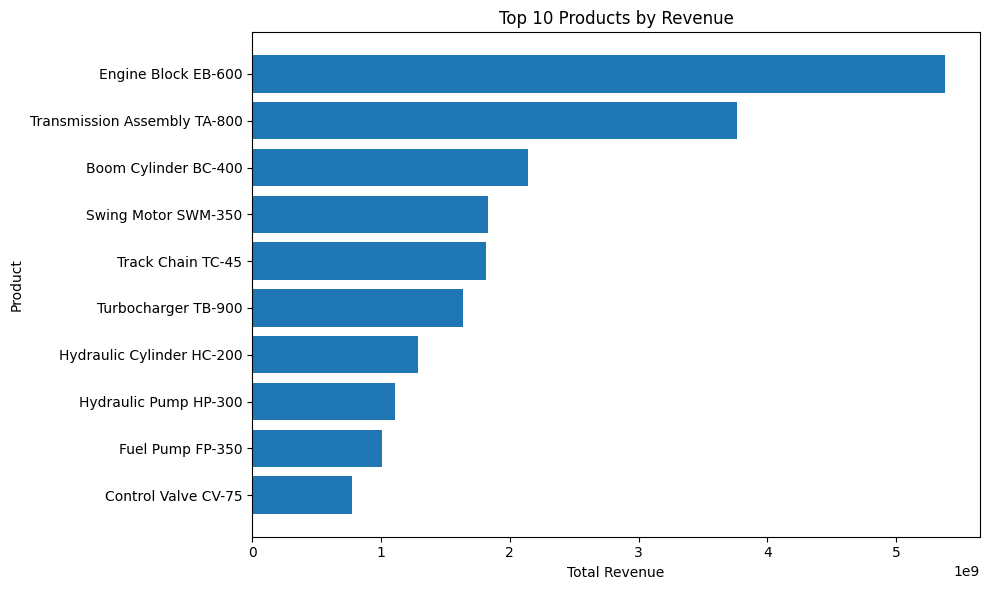

In [43]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products_revenue["product_name"],
    top_products_revenue["total_revenue"]
)

plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### **Top 10 products by quantity**

In [49]:
top_products_quantity = (
    product_performance
    .sort_values("total_units_sold", ascending=False)
    .head(10)
)

display(top_products_quantity)

,product_id,total_units_sold,total_revenue,number_of_transactions,average_unit_price,average_unit_cost,average_margin,product_name_x,product_name_y,product_name
28,P029,47066,185910700,4394,3950.0,2750.0,43.6,Pressure Sensor PS-90,Pressure Sensor PS-90,Pressure Sensor PS-90
9,P010,46964,1639043600,4434,34900.0,28900.0,20.8,Turbocharger TB-900,Turbocharger TB-900,Turbocharger TB-900
5,P006,46731,523387200,4440,11200.0,8650.0,29.5,Alternator ALT-500,Alternator ALT-500,Alternator ALT-500
10,P011,46612,1286491200,4462,27600.0,21500.0,28.4,Hydraulic Cylinder HC-200,Hydraulic Cylinder HC-200,Hydraulic Cylinder HC-200
6,P007,46468,67378600,4403,1450.0,980.0,48.0,Hydraulic Hose HH-60,Hydraulic Hose HH-60,Hydraulic Hose HH-60
20,P021,46364,2142016800,4370,46200.0,35600.0,29.8,Boom Cylinder BC-400,Boom Cylinder BC-400,Boom Cylinder BC-400
15,P016,46306,472321200,4437,10200.0,7800.0,30.8,Radiator RD-250,Radiator RD-250,Radiator RD-250
27,P028,46164,103869000,4403,2250.0,1450.0,55.2,Light Assembly LA-18,Light Assembly LA-18,Light Assembly LA-18
11,P012,45972,112631400,4407,2450.0,1800.0,36.1,Brake Pad BP-40,Brake Pad BP-40,Brake Pad BP-40
18,P019,45971,1829645800,4364,39800.0,31200.0,27.6,Swing Motor SWM-350,Swing Motor SWM-350,Swing Motor SWM-350


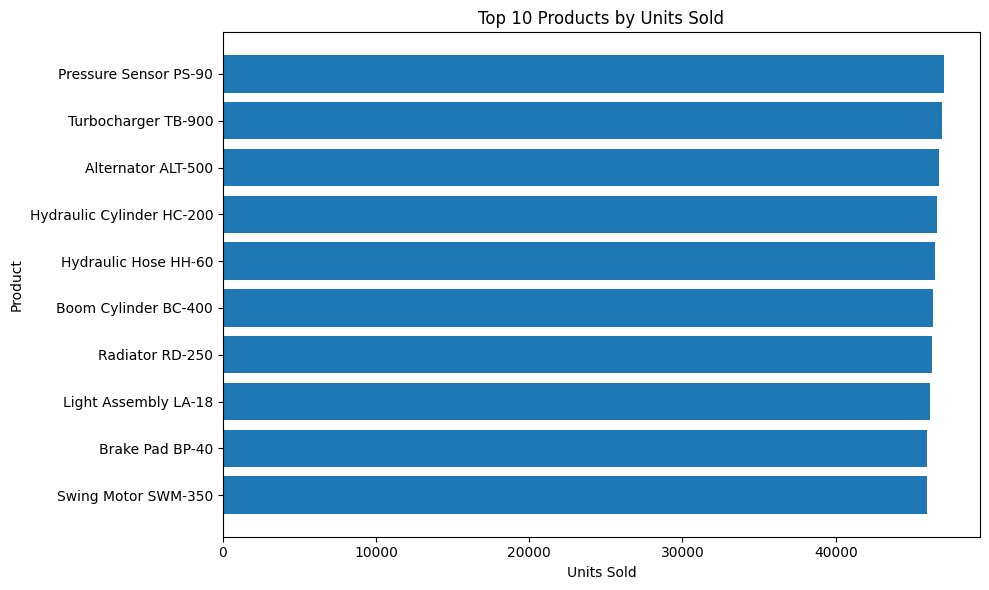

In [50]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products_quantity["product_name"].astype(str),
    top_products_quantity["total_units_sold"]
)

plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.title("Top 10 Products by Units Sold")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### **Fast-moving products**

In [52]:
quantity_75th = product_performance["total_units_sold"].quantile(0.75)

product_performance["movement_category"] = np.where(
    product_performance["total_units_sold"] >= quantity_75th,
    "Fast-Moving",
    "Other"
)

print("Fast-moving threshold:", quantity_75th)

fast_moving = (
    product_performance[
        product_performance["movement_category"] == "Fast-Moving"
    ]
    .sort_values("total_units_sold", ascending=False)
)

display(fast_moving.head(20))

Fast-moving threshold: 46116.0


,product_id,total_units_sold,total_revenue,number_of_transactions,average_unit_price,average_unit_cost,average_margin,product_name_x,product_name_y,product_name,movement_category
28,P029,47066,185910700,4394,3950.0,2750.0,43.6,Pressure Sensor PS-90,Pressure Sensor PS-90,Pressure Sensor PS-90,Fast-Moving
9,P010,46964,1639043600,4434,34900.0,28900.0,20.8,Turbocharger TB-900,Turbocharger TB-900,Turbocharger TB-900,Fast-Moving
5,P006,46731,523387200,4440,11200.0,8650.0,29.5,Alternator ALT-500,Alternator ALT-500,Alternator ALT-500,Fast-Moving
10,P011,46612,1286491200,4462,27600.0,21500.0,28.4,Hydraulic Cylinder HC-200,Hydraulic Cylinder HC-200,Hydraulic Cylinder HC-200,Fast-Moving
6,P007,46468,67378600,4403,1450.0,980.0,48.0,Hydraulic Hose HH-60,Hydraulic Hose HH-60,Hydraulic Hose HH-60,Fast-Moving
20,P021,46364,2142016800,4370,46200.0,35600.0,29.8,Boom Cylinder BC-400,Boom Cylinder BC-400,Boom Cylinder BC-400,Fast-Moving
15,P016,46306,472321200,4437,10200.0,7800.0,30.8,Radiator RD-250,Radiator RD-250,Radiator RD-250,Fast-Moving
27,P028,46164,103869000,4403,2250.0,1450.0,55.2,Light Assembly LA-18,Light Assembly LA-18,Light Assembly LA-18,Fast-Moving


### **Slow-moving products**

In [53]:
quantity_25th = product_performance["total_units_sold"].quantile(0.25)

product_performance["movement_category"] = np.select(
    [
        product_performance["total_units_sold"] >= quantity_75th,
        product_performance["total_units_sold"] <= quantity_25th
    ],
    [
        "Fast-Moving",
        "Slow-Moving"
    ],
    default="Medium-Moving"
)

display(
    product_performance[
        ["product_id", "product_name",
         "total_units_sold", "total_revenue",
         "movement_category"]
    ].head(20)
)

,product_id,product_name,total_units_sold,total_revenue,movement_category
0,P001,Hydraulic Pump HP-300,45389,1112030500,Medium-Moving
1,P002,Engine Oil Filter OF-90,45342,32646240,Medium-Moving
2,P003,Air Filter AF-120,45684,57105000,Medium-Moving
3,P004,Track Chain TC-45,45575,1813885000,Medium-Moving
4,P005,Fuel Injector FI-220,45026,380469700,Slow-Moving
5,P006,Alternator ALT-500,46731,523387200,Fast-Moving
6,P007,Hydraulic Hose HH-60,46468,67378600,Fast-Moving
7,P008,Bucket Tooth BT-10,45376,26318080,Medium-Moving
8,P009,Starter Motor SM-700,44946,669695400,Slow-Moving
9,P010,Turbocharger TB-900,46964,1639043600,Fast-Moving


### **Count products by movement category**

In [54]:
movement_summary = (
    product_performance["movement_category"]
    .value_counts()
    .reset_index()
)

movement_summary.columns = [
    "Movement Category",
    "Number of Products"
]

display(movement_summary)

,Movement Category,Number of Products
0,Medium-Moving,14
1,Slow-Moving,8
2,Fast-Moving,8


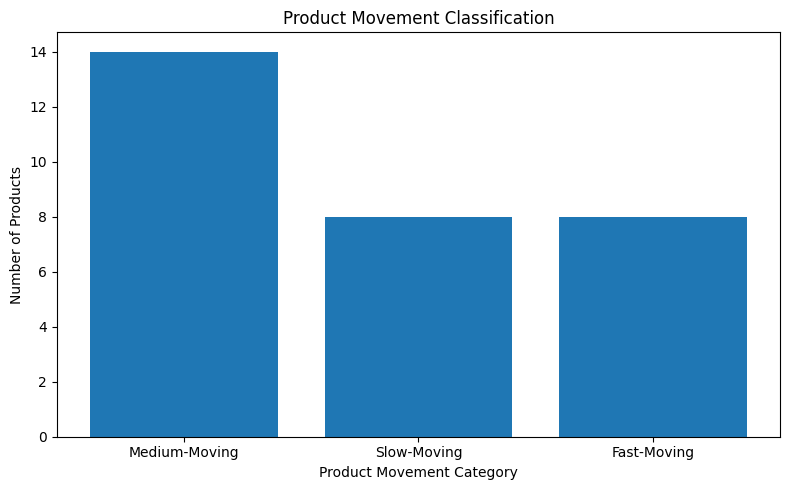

In [55]:
# Chart
plt.figure(figsize=(8, 5))

plt.bar(
    movement_summary["Movement Category"],
    movement_summary["Number of Products"]
)

plt.xlabel("Product Movement Category")
plt.ylabel("Number of Products")
plt.title("Product Movement Classification")

plt.tight_layout()
plt.show()

### **Products with zero sales**

In [56]:
product_sales_check = products[
    ["product_id", "product_name"]
].drop_duplicates().merge(
    product_performance[
        ["product_id", "total_units_sold", "total_revenue"]
    ],
    on="product_id",
    how="left"
)

product_sales_check["total_units_sold"] = (
    product_sales_check["total_units_sold"]
    .fillna(0)
)

product_sales_check["total_revenue"] = (
    product_sales_check["total_revenue"]
    .fillna(0)
)

zero_sales_products = product_sales_check[
    product_sales_check["total_units_sold"] == 0
]

print("Products with zero recorded sales:",
      len(zero_sales_products))

display(zero_sales_products.head(20))

Products with zero recorded sales: 0


,product_id,product_name,total_units_sold,total_revenue


### **Final KPI Summary**

In [63]:
# Calculate Week 4 KPIs

total_products_analysed = (
    product_performance["product_id"].nunique()
)

total_units_sold = (
    product_performance["total_units_sold"].sum()
)

total_revenue = (
    product_performance["total_revenue"].sum()
)

average_margin = (
    product_performance["average_margin"].mean()
)

fast_moving_count = (
    product_performance["movement_category"]
    .eq("Fast-Moving")
    .sum()
)

slow_moving_count = (
    product_performance["movement_category"]
    .eq("Slow-Moving")
    .sum()
)

medium_moving_count = (
    product_performance["movement_category"]
    .eq("Medium-Moving")
    .sum()
)


# Create KPI summary

week4_kpis = pd.DataFrame({
    "KPI": [
        "Products Analysed",
        "Total Units Sold",
        "Total Revenue",
        "Average Product Margin (%)",
        "Fast-Moving Products",
        "Medium-Moving Products",
        "Slow-Moving Products"
    ],
    "Value": [
        total_products_analysed,
        total_units_sold,
        total_revenue,
        average_margin,
        fast_moving_count,
        medium_moving_count,
        slow_moving_count
    ]
})

display(week4_kpis)

,KPI,Value
0,Products Analysed,3.000000e+01
1,Total Units Sold,1.368534e+06
2,Total Revenue,2.544739e+10
3,Average Product Margin (%),4.066667e+01
4,Fast-Moving Products,8.000000e+00
5,Medium-Moving Products,1.400000e+01
6,Slow-Moving Products,8.000000e+00
